In [35]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from data_cleaning import stats, standardization

## standardize the input data for clustering
see p. 52 MACHINE LEARNING FOR
ASSET MANAGERS
Marcos M. López de Prado

In [ ]:
relevant_data_uncleaned = pd.read_csv('data/relevant_data_uncleaned.csv')
relevant_data_uncleaned = relevant_data_uncleaned.drop(columns=["USRECD",'postTransactionAmounts.sharesOwnedFollowingTransaction'])
relevant_data_uncleaned

,amounts.shares,direct_ownership,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,t_1_percent_change_since_4d,t_10_percent_change_since_198d,transaction_month,filing_count_reportingOwner.name,high_frequency_trader,trades_14d,high_price,holding_change_percent,high_change_in_holdings
0,2000.0,1,53.63,True,False,False,False,0,0,2,1,0,1.0,1,-23.129409,0
1,200.0,1,6.25,True,False,False,False,0,1,2,11,0,7.0,0,-6.027728,0
2,200.0,1,6.50,True,False,False,False,0,1,2,11,0,7.0,0,-5.685048,0
3,2000.0,1,13.75,True,False,False,False,1,1,2,6,0,1.0,0,-33.333333,0
4,83340.0,1,5.25,False,False,True,False,1,1,2,24,0,13.0,0,-0.475322,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,100.0,1,23.81,True,False,False,False,1,0,7,22,0,6.0,1,-4.262575,0
141052,100.0,1,4.08,True,True,False,False,0,0,7,43,1,2.0,0,-0.150218,1
141053,164.0,1,19.64,True,False,False,False,1,0,7,21,0,1.0,1,-3.586267,0
141054,306.0,1,10.30,True,False,False,False,1,1,7,18,0,1.0,1,-1.845597,0


In [41]:
df = relevant_data_uncleaned

To account for the cyclical nature of calendar months, transaction month was encoded using sine and cosine transformations, ensuring that temporally adjacent months are represented with small Euclidean distances.

Wie interpretiert man die Variablen später?  
Einzelne Variablen:  

month_sin, month_cos nicht einzeln interpretieren  

Sie sind Koordinaten, keine Bedeutung für sich  

Zusammen interpretieren:  
Cluster-Zentrum → „typischer Monat“  
theta = np.arctan2(month_sin, month_cos)  
month = (theta * 12 / (2 * np.pi)) % 12  


Dann:  
 
month ≈ 1 → Januar  

month ≈ 12 → Dezember  

Das ist der „rücktransformierte“ Monatsschwerpunkt.  

In [42]:
df["month_sin"] = np.sin(2 * np.pi * df["transaction_month"] / 12) 
df["month_cos"] = np.cos(2 * np.pi * df["transaction_month"] / 12)
df

,amounts.shares,direct_ownership,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,t_1_percent_change_since_4d,t_10_percent_change_since_198d,transaction_month,filing_count_reportingOwner.name,high_frequency_trader,trades_14d,high_price,holding_change_percent,high_change_in_holdings,month_sin,month_cos
0,2000.0,1,53.63,True,False,False,False,0,0,2,1,0,1.0,1,-23.129409,0,0.866025,0.500000
1,200.0,1,6.25,True,False,False,False,0,1,2,11,0,7.0,0,-6.027728,0,0.866025,0.500000
2,200.0,1,6.50,True,False,False,False,0,1,2,11,0,7.0,0,-5.685048,0,0.866025,0.500000
3,2000.0,1,13.75,True,False,False,False,1,1,2,6,0,1.0,0,-33.333333,0,0.866025,0.500000
4,83340.0,1,5.25,False,False,True,False,1,1,2,24,0,13.0,0,-0.475322,1,0.866025,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,100.0,1,23.81,True,False,False,False,1,0,7,22,0,6.0,1,-4.262575,0,-0.500000,-0.866025
141052,100.0,1,4.08,True,True,False,False,0,0,7,43,1,2.0,0,-0.150218,1,-0.500000,-0.866025
141053,164.0,1,19.64,True,False,False,False,1,0,7,21,0,1.0,1,-3.586267,0,-0.500000,-0.866025
141054,306.0,1,10.30,True,False,False,False,1,1,7,18,0,1.0,1,-1.845597,0,-0.500000,-0.866025


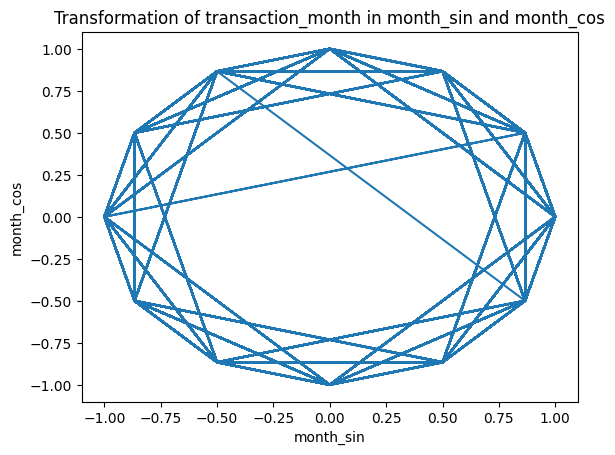

,amounts.shares,direct_ownership,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,t_1_percent_change_since_4d,t_10_percent_change_since_198d,filing_count_reportingOwner.name,high_frequency_trader,trades_14d,high_price,holding_change_percent,high_change_in_holdings,month_sin,month_cos
0,2000.0,1,53.63,True,False,False,False,0,0,1,0,1.0,1,-23.129409,0,0.866025,0.500000
1,200.0,1,6.25,True,False,False,False,0,1,11,0,7.0,0,-6.027728,0,0.866025,0.500000
2,200.0,1,6.50,True,False,False,False,0,1,11,0,7.0,0,-5.685048,0,0.866025,0.500000
3,2000.0,1,13.75,True,False,False,False,1,1,6,0,1.0,0,-33.333333,0,0.866025,0.500000
4,83340.0,1,5.25,False,False,True,False,1,1,24,0,13.0,0,-0.475322,1,0.866025,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,100.0,1,23.81,True,False,False,False,1,0,22,0,6.0,1,-4.262575,0,-0.500000,-0.866025
141052,100.0,1,4.08,True,True,False,False,0,0,43,1,2.0,0,-0.150218,1,-0.500000,-0.866025
141053,164.0,1,19.64,True,False,False,False,1,0,21,0,1.0,1,-3.586267,0,-0.500000,-0.866025
141054,306.0,1,10.30,True,False,False,False,1,1,18,0,1.0,1,-1.845597,0,-0.500000,-0.866025


In [46]:
plt.plot(df["month_sin"], df["month_cos"])
plt.title("Transformation of transaction_month in month_sin and month_cos")
plt.xlabel("month_sin")
plt.ylabel("month_cos")
plt.show()

df = df.drop(columns="transaction_month")
df

In [51]:
scaler_cols = df[['amounts.shares',
              'amounts.pricePerShare',
              'filing_count_reportingOwner.name',
              'trades_14d',
              'holding_change_percent'
              ]]

rest_cols = df[['direct_ownership',
       'reportingOwner.relationship.isDirector',
       'reportingOwner.relationship.isOfficer',
       'reportingOwner.relationship.isTenPercentOwner',
       'reportingOwner.relationship.isOther',
       't_1_percent_change_since_4d',
       't_10_percent_change_since_198d',
       'high_frequency_trader',
       'high_price',
       'high_change_in_holdings',
       'month_sin',
       'month_cos']]

In [58]:
sc = StandardScaler() # Standardization
scaled = sc.fit_transform(scaler_cols)

scaler_cols_df = pd.DataFrame(scaled, columns=scaler_cols.columns)

df_left = scaler_cols_df
df_right = rest_cols

df_scaled = df_left.join(df_right, how="left")
df_scaled


,amounts.shares,amounts.pricePerShare,filing_count_reportingOwner.name,trades_14d,holding_change_percent,direct_ownership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,t_1_percent_change_since_4d,t_10_percent_change_since_198d,high_frequency_trader,high_price,high_change_in_holdings,month_sin,month_cos
0,-0.002870,-0.004828,-0.403910,-0.267290,0.003040,1,True,False,False,False,0,0,0,1,0,0.866025,0.500000
1,-0.002876,-0.004914,-0.400370,-0.239858,0.003153,1,True,False,False,False,0,1,0,0,0,0.866025,0.500000
2,-0.002876,-0.004914,-0.400370,-0.239858,0.003155,1,True,False,False,False,0,1,0,0,0,0.866025,0.500000
3,-0.002870,-0.004900,-0.402140,-0.267290,0.002972,1,True,False,False,False,1,1,0,0,0,0.866025,0.500000
4,-0.002621,-0.004916,-0.395768,-0.212426,0.003189,1,False,False,True,False,1,1,0,0,1,0.866025,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,-0.002876,-0.004882,-0.396476,-0.244430,0.003164,1,True,False,False,False,1,0,0,1,0,-0.500000,-0.866025
141052,-0.002876,-0.004918,-0.389042,-0.262718,0.003192,1,True,True,False,False,0,0,1,0,1,-0.500000,-0.866025
141053,-0.002876,-0.004890,-0.396830,-0.267290,0.003169,1,True,False,False,False,1,0,0,1,0,-0.500000,-0.866025
141054,-0.002875,-0.004907,-0.397892,-0.267290,0.003180,1,True,False,False,False,1,1,0,1,0,-0.500000,-0.866025


Elbogenmethode optimales k finden und einsetzten

In [54]:
X = df_scaled.values

idx = np.random.choice(len(X), 20_000, replace=False)
X_sub = X[idx]
silhouettes = []
for k in range(2, 11):
    km = MiniBatchKMeans(
        n_clusters=k,
        n_init=5,
        batch_size=2048,
        random_state=42
    )
    labels = km.fit_predict(X)
    silhouettes.append(silhouette_score(X_sub, labels[idx]))

silhouettes

[0.5681365338641503,
 0.4528139797932726,
 0.17630099109529643,
 0.17543471600907132,
 0.15124640110918372,
 0.1545615509068353,
 0.14687209735068188,
 0.14805249956194433,
 0.15008667117802157]

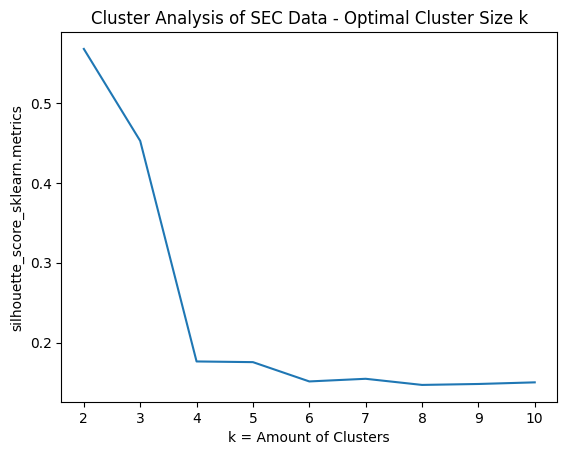

In [55]:
ys = silhouettes
xs = [x for x in range(2, 11)]

plt.plot(xs, ys)
plt.title("Cluster Analysis of SEC Data - Optimal Cluster Size k")
plt.xlabel("k = Amount of Clusters")
plt.ylabel("silhouette_score_sklearn.metrics")
plt.show()


Clusteranalyse durchführen mit k = 2


In [61]:
kmeans_k2 = KMeans(
    n_clusters=2,
    init="k-means++",
    n_init=30,
    random_state=42
)

feature_cols = df_scaled.columns

X = df_scaled[feature_cols].values

df_scaled["kmeans_k2"] = kmeans_k2.fit_predict(X)

cluster_centers = (
    pd.DataFrame(kmeans_k2.cluster_centers_, columns=feature_cols)
      .assign(cluster=lambda d: d.index)
)

cluster_centers
cluster_centers.to_csv('out.csv', index=False)


In [ ]:
all_df_of_close_data = pd.read_csv('data/all_df_of_close_data.csv')
all_df_of_close_data =  all_df_of_close_data.drop(columns=["Unnamed: 0", "Unnamed: 0.1"])
all_df_of_close_data


,Unnamed: 0.1,issuer.name,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,...,355,356,357,358,359,360,361,362,363,364
0,0,ABBOTT LABORATORIES,ABT,TILTON GLENN F,2009-02-25,2000.0,53.63,10647.0,D,True,...,18.450430,18.676229,18.730982,18.806242,18.604395,18.604395,18.604395,18.611233,18.464115,18.587284
1,1,SIERRA BANCORP,BSRR,Scearcy Lynda,2009-02-26,200.0,6.25,3518.0,D,True,...,6.462494,6.398380,6.411205,6.500963,6.500963,6.500963,6.500963,6.449671,6.507371,6.494549
2,2,SIERRA BANCORP,BSRR,Scearcy Lynda,2009-02-26,200.0,6.50,3718.0,D,True,...,6.462494,6.398380,6.411205,6.500963,6.500963,6.500963,6.500963,6.449671,6.507371,6.494549
3,3,"ENSIGN GROUP, INC",ENSG,Nackel John G.,2009-02-27,2000.0,13.75,8000.0,D,True,...,4.050258,4.073599,4.127295,4.127295,4.127295,3.931201,3.963884,3.952211,3.949878,3.889182
4,4,CALPINE CORP,CPN,"LSP Cal Holdings II, LLC",2009-02-25,83340.0,5.25,17616711.0,D,False,...,11.230000,11.400000,11.300000,11.290000,11.350000,11.350000,11.350000,11.460000,11.310000,11.240000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,237350,"MainStreet Bancshares, Inc.",MNSB,ECHLOV RUSSELL,2023-07-31,100.0,23.81,2446.0,D,True,...,16.334618,16.256369,16.217241,16.706301,16.344395,16.344395,16.344395,16.373741,16.227022,16.090086
141052,237351,flooidCX Corp.,FLCX,Danzik Dennis M,2023-07-28,100.0,4.08,66670.0,D,True,...,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000
141053,237352,AMES NATIONAL CORP,ATLO,Cassabaum Michelle R,2023-07-31,164.0,19.64,4737.0,D,True,...,17.545956,17.029333,17.278076,17.498119,18.005171,18.397419,18.397419,18.397419,18.053009,17.517252
141054,237359,Citizens Community Bancorp Inc.,CZWI,Bourget Kristina M,2023-07-28,306.0,10.30,16886.0,D,True,...,12.207207,11.914000,12.041056,12.041056,12.041056,12.050830,12.158339,12.158339,12.774075,12.793622


In [ ]:
# Mean Returns for each cluster one share each filling
x_0 = all_df_of_close_data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(1, 364)]
Xt = all_df_of_close_data[day_cols].to_numpy()
return_matrix = Xt - x_0
return_df = pd.DataFrame(return_matrix)
mean_return = return_df.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Mean Returns for one share each filling')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of Price_0 - Price_t\nin $')

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.show()


# Total Mean Returns for each cluster: actual return with amount of shares
n = all_df_of_close_data['amounts.shares'].to_numpy()[:, None]
x_0 = all_df_of_close_data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(1, 364)]
Xt = all_df_of_close_data[day_cols].to_numpy()
return_matrix = (Xt - x_0)*n
return_df = pd.DataFrame(return_matrix)
mean_return = return_df.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Total Mean Returns')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of return times the amount of shares in $')

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.show()


Visualisierung der Cluster

Performance pro cluster vergleichen

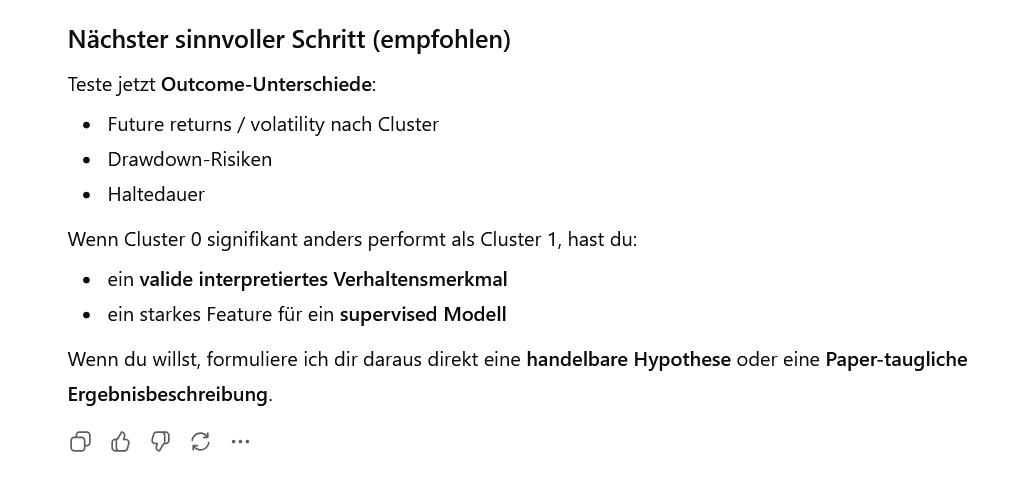

Alternative cluster Algos

preisrohdaten, bzw demeant usw und standardized_relevant_data_uncleaned

erkenntnisse auf targetengeneering anwenden

<Axes: >

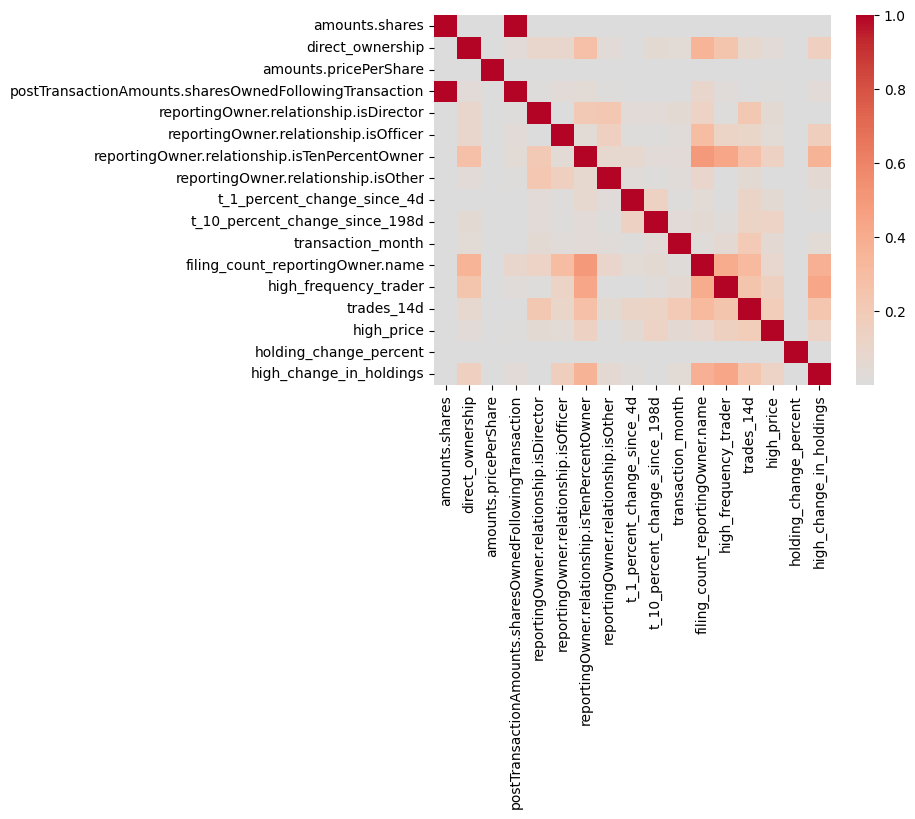

In [ ]:
corr_matrix = standardized_relevant_data_uncleaned.corr(numeric_only=False).abs()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

In [ ]:
# covariance matrix on absolute price, return per stock, absolute return weighted with amount of shares,  demeaned, percent
def plot_heatmap(df, ax, plt_title = "Return Xt - x_0"):
    corr_matrix = df.corr(numeric_only=False).abs()
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=ax)
    ax.set_title(plt_title)    

day_cols = [str(i) for i in range(364)]
absolute_price_df = pd.DataFrame(all_df_of_close_data[day_cols])

# return per stock: returns for one share each filling
x_0 = data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(0, 364)]
Xt = data[day_cols].to_numpy()
return_matrix = Xt - x_0
simple_return_df = pd.DataFrame(return_matrix)

# absolute return weighted with amount of shares
n = all_df_of_close_data['amounts.shares'].to_numpy()[:, None]
x_0 = all_df_of_close_data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(0, 364)]
Xt = all_df_of_close_data[day_cols].to_numpy()
return_matrix = (Xt - x_0)*n
weighted_return_df = pd.DataFrame(return_matrix)

# demeaned
# with matrix or else warning
abs_mat = all_df_of_close_data[day_cols].to_numpy(dtype=float)
row_mean = np.nanmean(abs_mat, axis=1, keepdims=True)
demean_mat = abs_mat - row_mean
demean_df = pd.DataFrame(demean_mat)

#percent
# calculate percentage since day 0
ref = all_df_of_close_data[day_cols[0]].to_numpy(dtype=float)[:, None]
ref = np.where(ref == 0, np.nan, ref)
percent_mat = (abs_mat - ref) / ref
percent_df = pd.DataFrame(percent_mat)

# plot absolute, demeaned and percentage in one pic
fig, axs = plt.subplots(2, 3, figsize=(12, 12), sharex=True)

plot_heatmap(absolute_price_df,  axs[0, 0], "Covariance of Absolute Price")
plot_heatmap(simple_return_df,   axs[0, 1], "Covariance of Simple Return Xt - x_0")
plot_heatmap(weighted_return_df, axs[0, 2], "Covariance of Weighted Return (Xt - x_0)*n")
plot_heatmap(demean_df,          axs[1, 0], "Covariance of Demeaned Price")
plot_heatmap(percent_df,         axs[1, 1], "Covariance of Percent (abs_mat - ref)/ref")


plt.tight_layout()
#plt.savefig('exports/descriptive_random_state_69.png', dpi=500)
plt.show()


## SNIPPET 4.1 BASE CLUSTERING  

MACHINE LEARNING FOR
ASSET MANAGERS
Marcos M. López de Prado

In [ ]:
x, silh=((1-corr0.fillna(0))/2.)**.5, pd.Series()

In [2]:
def clusterKMeansBase(corr0, maxNumClusters=10, n_init=10):
    x, silh=((1-corr0.fillna(0))/2.)**.5, pd.Series()  # observation matrix
    for init in range(n_init):
        for i in xrange(2, maxNumClusters+1):
            kmeans_=KMeans(n_clusters=i, n_jobs=1, n_init=1)
            kmeans_=kmeans_.fit(x)
            silh_=silhouette_samples(x, kmeans_.labels_)
            stat=(silh_.mean()/silh_.std(), silh.mean()/silh.std())
            if np.isnan(stat[1]) or stat[0]>stat[1]:
                silh, kmeans=silh_, kmeans_
    newIdx=np.argsort(kmeans.labels_)
    corr1=corr0.iloc[newIdx]  # reorder rows

    corr1=corr1.iloc[:,newIdx]  # reorder columns
    clstrs={i:corr0.columns[np.where(kmeans.labels_==i)[0]].tolist()\
            for i in np.unique(kmeans.labels_)}  # cluster members
    silh=pd.Series(silh, index=x.index)
    return corr1, clstrs, silh
